# TPCC Basic Analysis
20260417
-101907
This notebook visualizes the basic aggregate metrics for the PostgreSQL TPCC benchmark result in this directory.

In [4]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')

result_dir = Path(
    '/Users/yohasebe/Documents/dbfs/benchmarking/results/tpcc/postgres/20260417-101907'
)
summary_path = next(result_dir.glob('*.summary.json'))
results_path = next(result_dir.glob('*.results.csv'))
samples_path = next(result_dir.glob('*.samples.csv'))
metrics_path = next(result_dir.glob('*.metrics.json'))
procedure_paths = sorted(result_dir.glob('*.results.*.csv'))

with summary_path.open() as handle:
    summary = json.load(handle)
with metrics_path.open() as handle:
    metrics = json.load(handle)

results_df = pd.read_csv(results_path)
samples_df = pd.read_csv(samples_path)
procedure_dfs = {
    path.stem.split('.results.', 1)[1]: pd.read_csv(path)
    for path in procedure_paths
}

print(f'Result directory: {result_dir}')
print(f'Loaded {len(procedure_dfs)} procedure-level result files.')

Result directory: /Users/yohasebe/Documents/dbfs/benchmarking/results/tpcc/postgres/20260417-101907
Loaded 5 procedure-level result files.


In [5]:
summary_table = pd.DataFrame([
    ('Benchmark', summary['Benchmark Type']),
    ('DBMS', summary['DBMS Type']),
    ('Final State', summary['Final State']),
    ('Measured Requests', summary['Measured Requests']),
    ('Throughput (req/s)', summary['Throughput (requests/second)']),
    ('Goodput (req/s)', summary['Goodput (requests/second)']),
    ('Average Latency (ms)',
     summary['Latency Distribution']['Average Latency (microseconds)'] / 1000),
    ('Median Latency (ms)',
     summary['Latency Distribution']['Median Latency (microseconds)'] / 1000),
    ('P95 Latency (ms)',
     summary['Latency Distribution']['95th Percentile Latency (microseconds)']
     / 1000),
    ('P99 Latency (ms)',
     summary['Latency Distribution']['99th Percentile Latency (microseconds)']
     / 1000),
    ('Max Latency (ms)',
     summary['Latency Distribution']['Maximum Latency (microseconds)'] / 1000),
],
                             columns=['Metric', 'Value'])
summary_table

,Metric,Value
0,Benchmark,tpcc
1,DBMS,POSTGRES
2,Final State,EXIT
3,Measured Requests,39266
4,Throughput (req/s),654.433
5,Goodput (req/s),651.533
6,Average Latency (ms),1.516
7,Median Latency (ms),1.231
8,P95 Latency (ms),3.680
9,P99 Latency (ms),6.149


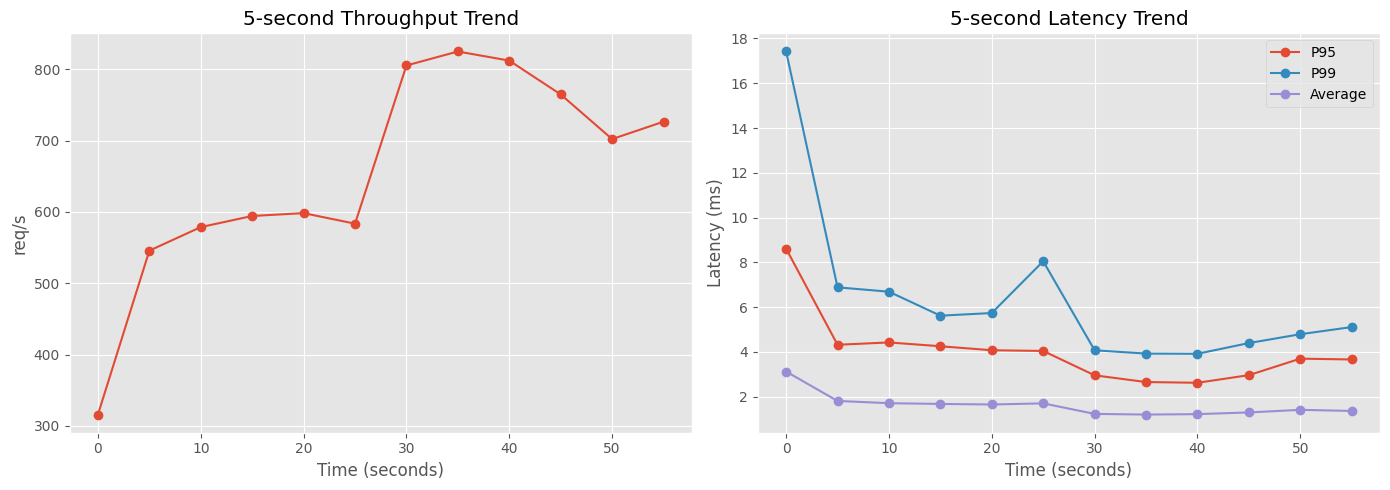

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['Time (seconds)'],
             results_df['Throughput (requests/second)'],
             marker='o',
             label='Throughput')
axes[0].set_title('5-second Throughput Trend')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('req/s')

axes[1].plot(results_df['Time (seconds)'],
             results_df['95th Percentile Latency (millisecond)'],
             marker='o',
             label='P95')
axes[1].plot(results_df['Time (seconds)'],
             results_df['99th Percentile Latency (millisecond)'],
             marker='o',
             label='P99')
axes[1].plot(results_df['Time (seconds)'],
             results_df['Average Latency (millisecond)'],
             marker='o',
             label='Average')
axes[1].set_title('5-second Latency Trend')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Latency (ms)')
axes[1].legend()

fig.tight_layout()
plt.show()

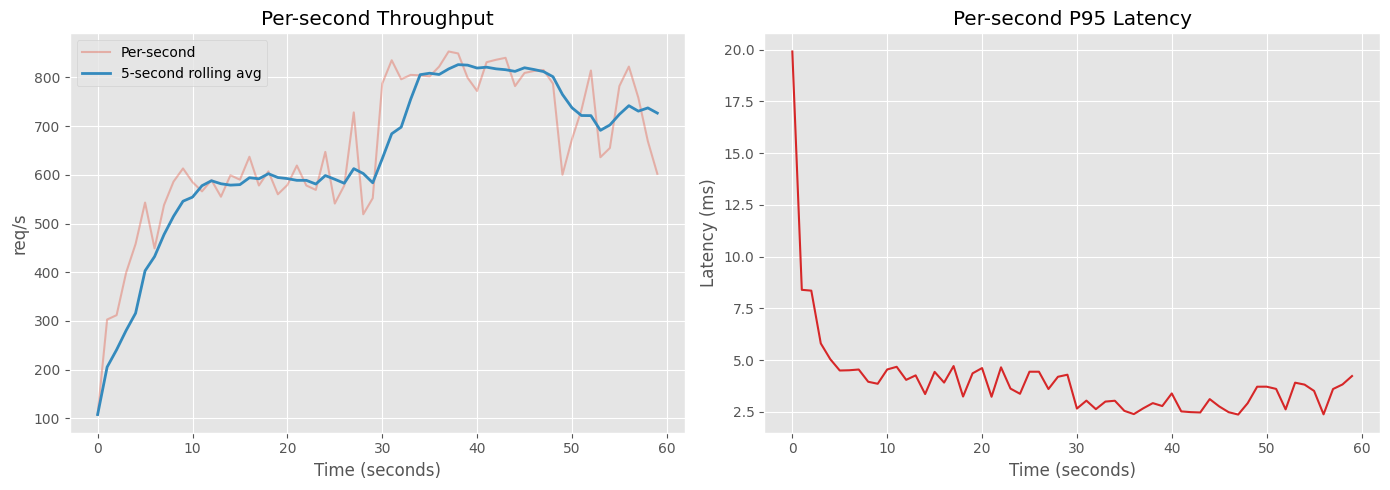

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rolling_window = 5
samples_df['Throughput Rolling'] = samples_df[
    'Throughput (requests/second)'].rolling(rolling_window,
                                            min_periods=1).mean()
samples_df['P95 Latency (ms)'] = samples_df[
    '95th Percentile Latency (microseconds)'] / 1000

axes[0].plot(samples_df['Time (seconds)'],
             samples_df['Throughput (requests/second)'],
             alpha=0.35,
             label='Per-second')
axes[0].plot(samples_df['Time (seconds)'],
             samples_df['Throughput Rolling'],
             linewidth=2,
             label='5-second rolling avg')
axes[0].set_title('Per-second Throughput')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('req/s')
axes[0].legend()

axes[1].plot(samples_df['Time (seconds)'],
             samples_df['P95 Latency (ms)'],
             color='tab:red')
axes[1].set_title('Per-second P95 Latency')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Latency (ms)')

fig.tight_layout()
plt.show()

,Procedure,Avg Throughput (req/s),Avg Latency (ms),P95 Latency (ms),Max Latency (ms)
1,NewOrder,294.083,2.108,3.289,78.388
3,Payment,280.983,0.929,1.649,162.953
0,Delivery,26.933,4.883,7.335,111.058
2,OrderStatus,26.450,0.991,2.218,36.834
4,StockLevel,25.983,0.853,1.443,35.039


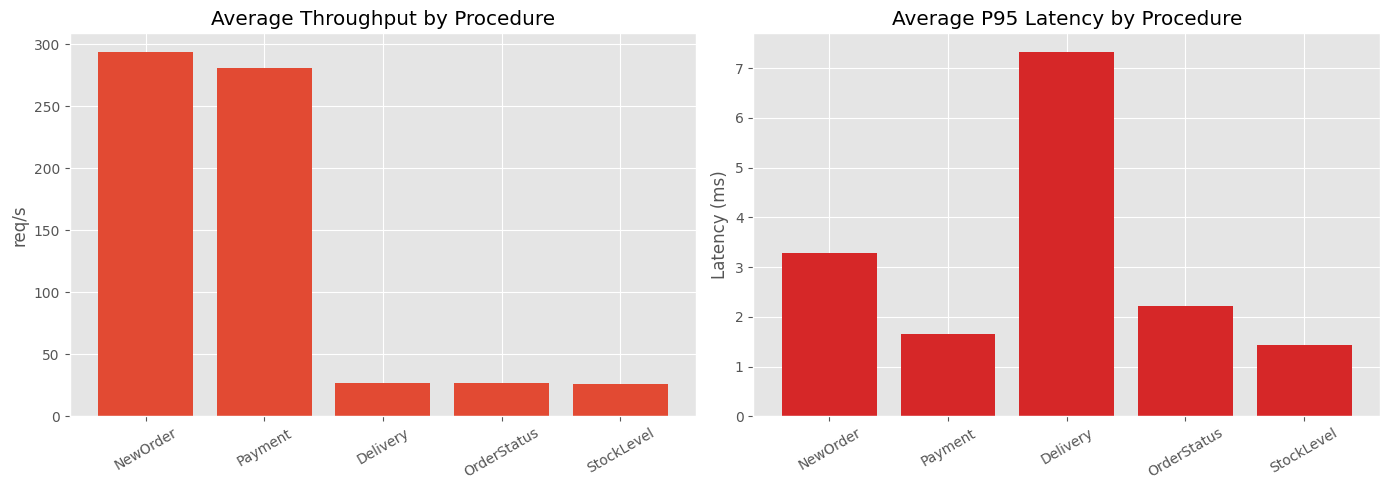

In [8]:
procedure_summary = pd.DataFrame([{
    'Procedure':
    name,
    'Avg Throughput (req/s)':
    df['Throughput (requests/second)'].mean(),
    'Avg Latency (ms)':
    df['Average Latency (millisecond)'].mean(),
    'P95 Latency (ms)':
    df['95th Percentile Latency (millisecond)'].mean(),
    'Max Latency (ms)':
    df['Maximum Latency (millisecond)'].max(),
} for name, df in procedure_dfs.items()]).sort_values('Avg Throughput (req/s)',
                                                      ascending=False)

display(procedure_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(procedure_summary['Procedure'],
            procedure_summary['Avg Throughput (req/s)'])
axes[0].set_title('Average Throughput by Procedure')
axes[0].set_ylabel('req/s')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(procedure_summary['Procedure'],
            procedure_summary['P95 Latency (ms)'],
            color='tab:red')
axes[1].set_title('Average P95 Latency by Procedure')
axes[1].set_ylabel('Latency (ms)')
axes[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

,Metric,Value
0,Committed Transactions,"128,111.000"
1,Rolled Back Transactions,513.000
2,Blocks Read,"14,417.000"
3,Blocks Hit,"58,654,656.000"
4,Buffer Cache Hit Ratio,1.000
5,Rows Inserted,"2,452,190.000"
6,Rows Updated,"1,247,983.000"
7,Rows Deleted,"47,447.000"


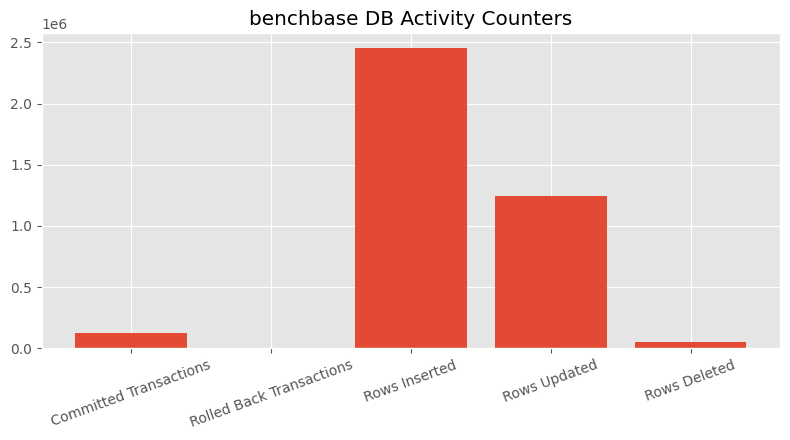

In [9]:
pg_stat_database = pd.DataFrame(metrics.get('pg_stat_database', []))
benchbase_db = pg_stat_database[pg_stat_database['datname'] ==
                                'benchbase'].copy()
numeric_columns = [
    'xact_commit', 'xact_rollback', 'blks_read', 'blks_hit', 'tup_inserted',
    'tup_updated', 'tup_deleted'
]
for column in numeric_columns:
    benchbase_db[column] = pd.to_numeric(benchbase_db[column], errors='coerce')

if not benchbase_db.empty:
    hit_ratio = benchbase_db['blks_hit'].iloc[0] / (
        benchbase_db['blks_hit'].iloc[0] + benchbase_db['blks_read'].iloc[0])
    db_summary = pd.DataFrame([
        ('Committed Transactions', benchbase_db['xact_commit'].iloc[0]),
        ('Rolled Back Transactions', benchbase_db['xact_rollback'].iloc[0]),
        ('Blocks Read', benchbase_db['blks_read'].iloc[0]),
        ('Blocks Hit', benchbase_db['blks_hit'].iloc[0]),
        ('Buffer Cache Hit Ratio', hit_ratio),
        ('Rows Inserted', benchbase_db['tup_inserted'].iloc[0]),
        ('Rows Updated', benchbase_db['tup_updated'].iloc[0]),
        ('Rows Deleted', benchbase_db['tup_deleted'].iloc[0]),
    ],
                              columns=['Metric', 'Value'])
    display(db_summary)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_df = db_summary[db_summary['Metric'].isin([
        'Committed Transactions', 'Rolled Back Transactions', 'Rows Inserted',
        'Rows Updated', 'Rows Deleted'
    ])]
    ax.bar(plot_df['Metric'], plot_df['Value'])
    ax.set_title('benchbase DB Activity Counters')
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()
else:
    print('benchbase database metrics were not found in metrics.json')